## Best Combination CV

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
mod = "Grid_Combination"

In [4]:
best_lambda_config = GlobalSetting.get_config_by_type(mod)
best_lamda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lamda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [5]:
abc_relm_cv  = ArtificialBeeColonyElmCV(
    feature_size= features_size,
    hidden_size         = best_lamda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lamda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_relm_cv.employed_bee_apply_algo3()
abc_relm_cv.onlooker_bee_apply_algo2()

In [6]:
results_df , convergence_df , scout_df = abc_testing(abc_relm_cv, x_train, y_train, x_test, y_test)
results_df.describe()

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.775000,0.776677,0.772917,0.776211,0.777083,0.773749,0.773012,0.775000,0.551438,55.500000
std,0.038841,0.038539,0.061923,0.049719,0.042432,0.042750,0.053378,0.038841,0.078108,8.803408
min,0.703125,0.709677,0.656250,0.694444,0.718750,0.698413,0.673077,0.703125,0.406449,41.000000
25%,0.750000,0.750000,0.718750,0.737185,0.750000,0.743952,0.729007,0.750000,0.500245,48.250000
50%,0.781250,0.781250,0.781250,0.781250,0.781250,0.781250,0.781250,0.781250,0.562500,55.500000
75%,0.808594,0.794118,0.812500,0.810988,0.781250,0.809375,0.811238,0.808594,0.617260,62.750000
max,0.843750,0.888889,0.906250,0.892857,0.906250,0.852941,0.884146,0.843750,0.692935,70.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Combination_CV_F1-Score.png


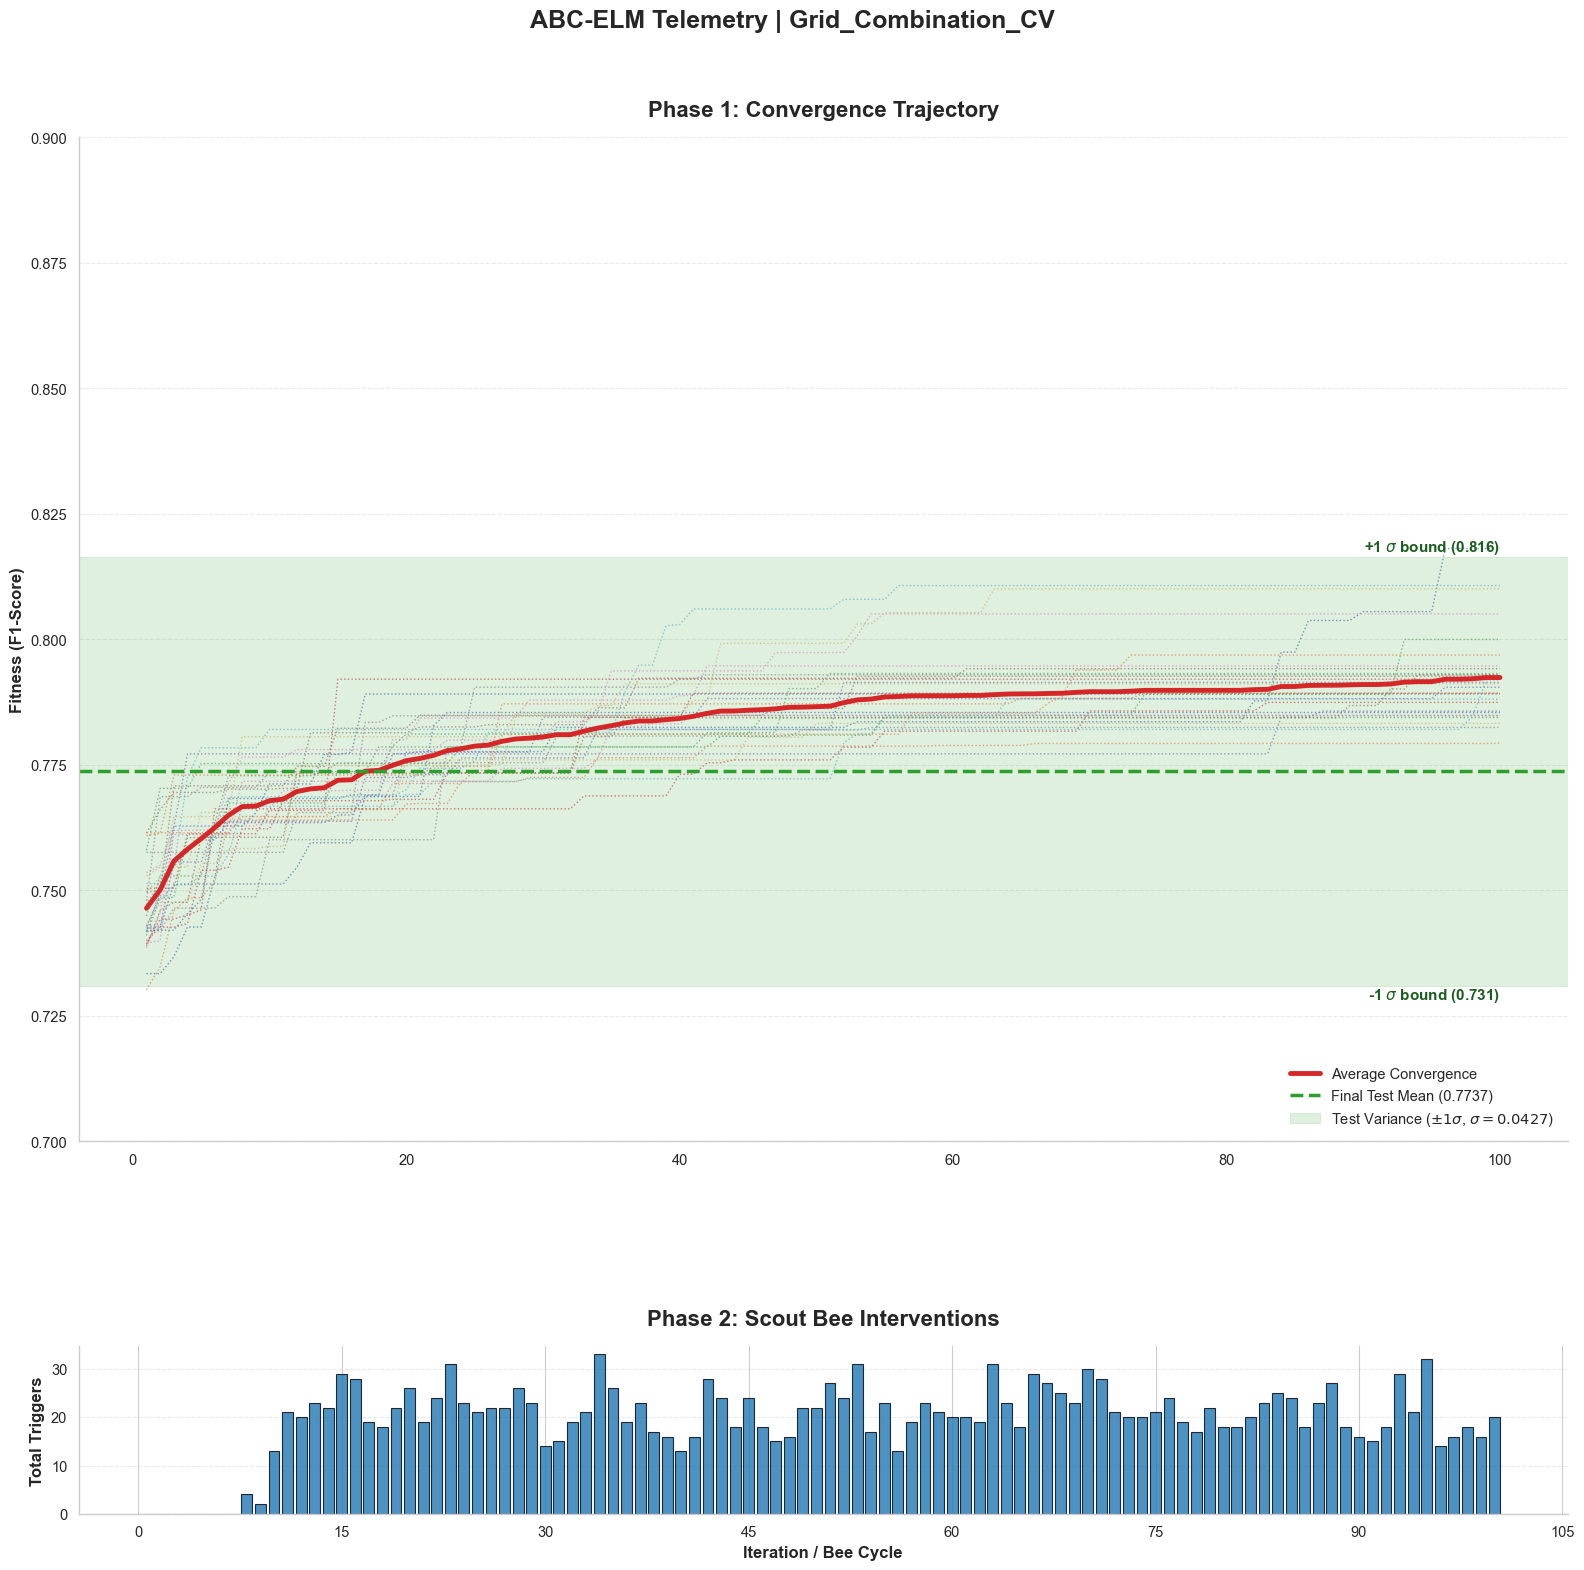

In [7]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,f"{mod}_CV",results_df,is_final_record=True)

In [8]:
best_lamda_hidden_size , best_lamda_lambda_value

(64, 0.0625)

In [9]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")

GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')

GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Combination_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Combination_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Combination_Scout_History.csv
